In [1]:
## Preliminaries

using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

using AdvancedHMC
using ArviZ
using BumpCosmologyGWTC3
using CairoMakie
using Colors
using Cosmology
using DataFrames
using DimensionalData
using Distributions
using GaussianKDEs
using HDF5
using InferenceObjects
#using Interpolations
using JSON
using LaTeXStrings
using MCMCChainsStorage
using NCDatasets
using PairPlots
using PolyLog
using PopModels
using Printf
using ProgressLogging
using Random
using StatsBase
using SpecialFunctions
using StatsFuns
using Trapz
using Turing
using Unitful
using UnitfulAstro
using UnitfulChainRules

include("plots.jl")

  Activating project at `~/35_GWTC4_Mod/GWTC4_35_m1m2z_Feb23/no_pairing/m2_peak`


h_plot (generic function with 1 method)

# Plot Specification

In [2]:
## Set up paths

## Output Directory for Plots and Astro Comparison Plot
outdir = "../../../Plots/no_pairing_m2_peak_"

## Plot Specifications
xlabelsize = 30
ylabelsize = 30
xticklabelsize = 23
yticklabelsize = 23
titlesize = 35
draws = 500

plot_save = false

false

### $p_{cut} = 0.5$: Main Plots Use This Trace

In [3]:
trace_samples_0p5 = from_netcdf(joinpath(@__DIR__, "..", "data", "chains_0.5.nc"))
ne_min = dropdims(minimum(trace_samples_0p5.posterior.Neff_samps, dims=(:chain, :draw)); dims=(:chain, :draw))
ns_min = minimum(trace_samples_0p5.posterior.Neff_sel)
@info "p_cut = 0.5, minimum Neff_samps: $(round(minimum(ne_min), digits=2)), minimum Neff_sel = $(round(ns_min, digits=1)), 4*Nobs = $(4*length(dims(trace_samples_0p5.posterior, :event)))"
trace = trace_samples_0p5

┌ Info: p_cut = 0.5, minimum Neff_samps: 4.13, minimum Neff_sel = 872.2, 4*Nobs = 460
└ @ Main /mnt/home/sroy1/35_GWTC4_Mod/GWTC4_35_m1m2z_Feb23/no_pairing/m2_peak/scripts/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W4sdnNjb2RlLXJlbW90ZQ==.jl:4


InferenceData with groups:
  > posterior
  > sample_stats

### $p_{cut} = 0.1$

In [4]:
trace_samples_0p1 = from_netcdf(joinpath(@__DIR__, "..", "data", "chains_0.1.nc"))

InferenceData with groups:
  > posterior
  > sample_stats

### $p_{cut} = 0.9$

In [5]:
trace_samples_0p9 = from_netcdf(joinpath(@__DIR__, "..", "data", "chains.nc"))

InferenceData with groups:
  > posterior
  > sample_stats

# $m_1-m_2$ Marginals

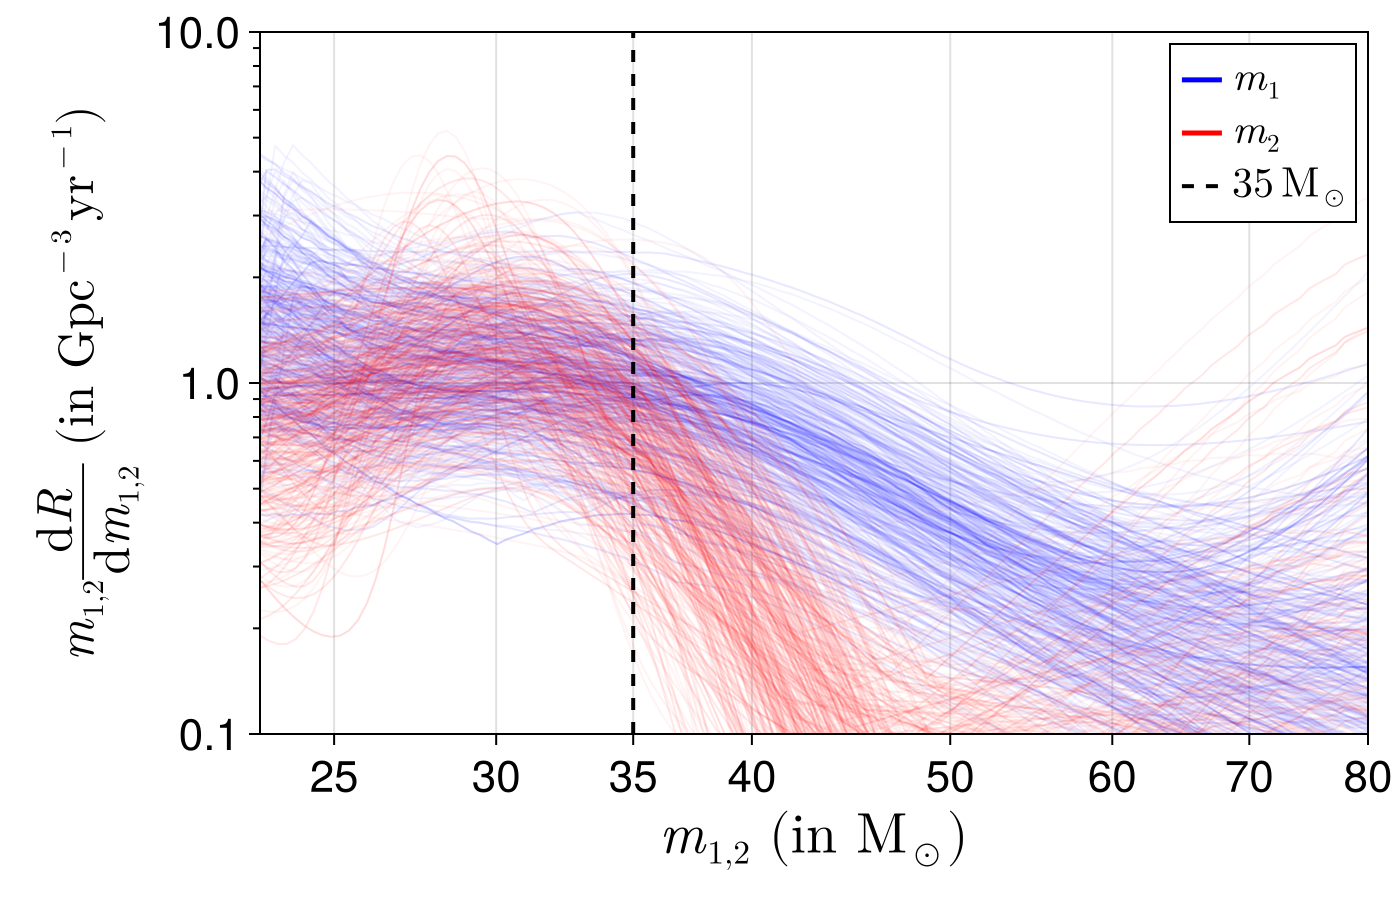

In [6]:
z_plot = 0.0

function marginal_m1m2_plot_paper(trace;
    limits=(23.0, 80.0, 0.1, 10.0),
    yticks=[0.01, 0.1, 1, 10, 100],
    yminorticks=[0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,
                 0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,2,3,4,5,6,7,8,9,20],
    draws=1000,
    ntrace=500,
    rng=Random.default_rng()
)

    f = Figure(size=(700, 450))

    a = Axis(f[1,1],
        xlabel = L"m_{1,2}~(\mathrm{in~}\mathrm{M}_\odot)",
        ylabel = L"m_{1,2} \frac{\mathrm{d} R}{\mathrm{d} m_{1,2}}~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1})",
        xscale = log10, yscale = log10,
        xticks = [25, 30, 35, 40, 50, 60, 70, 80],
        xtickformat = "{:.0f}",
        yticks = (yticks, string.(yticks)),
        yminorticks = yminorticks,
        yminorticksvisible = true,
        xlabelsize = 28,
        ylabelsize = 25,
        xticklabelsize = 22,
        yticklabelsize = 22,
        limits = limits
    )

    marginal_component_plot!(a, trace; kind=:m1, z_plot=z_plot,
        ms=exp.(log(m_bh_min):0.01:log(m_bh_max)),
        qs=0.001:0.01:1,
        draws=draws,
        ntrace=ntrace,
        rng=rng,
        color=:blue
    )

    marginal_component_plot!(a, trace; kind=:m2, z_plot=z_plot,
        ms=exp.(log(20.0):0.01:log(m_bh_max)),
        qs=0.001:0.01:1,
        draws=draws,
        ntrace=ntrace,
        rng=rng,
        color=:red
    )

    # dummy legend entries
    lines!(a, [NaN], [NaN], color=:blue, linewidth=2.5, label=L"m_1")
    lines!(a, [NaN], [NaN], color=:red, linewidth=2.5, label=L"m_2")

    vlines!(a, [35.0], color=:black, linewidth=2, linestyle=:dash, label=L"35\,\mathrm{M}_\odot")

    axislegend(a, position=:rt, labelsize=21, framevisible=true)

    return f
end


function marginal_component_plot!(a, trace;
    kind::Symbol, z_plot,
    ms, qs, draws, ntrace,
    rng, color
)

    p = trace.posterior
    sampled_cd = Tuple{Int,Int}[]

    @progress for i in 1:draws
        d = rand(rng, span(dims(p, :draw)))
        c = rand(rng, 1:length(dims(p, :chain)))
        push!(sampled_cd, (c, d))
    end

    trace_inds = rand(rng, 1:draws, min(ntrace, draws))

    for idx in trace_inds

        c, d = sampled_cd[idx]
        log_dN = log_dN_from_chain_sample(trace, d, c)

        vals = map(ms) do m

            integrand = map(qs) do q

                if kind == :m1
                    m2 = q*m
                    if m2 < m_bh_min
                        zero(m)
                    else
                        exp(log_dN(m, q, z_plot))
                    end

                elseif kind == :m2
                    m1 = m/q
                    if m1 < m_bh_min || m1 > m_bh_max
                        zero(m)
                    else
                        exp(log_dN(m1, q, z_plot))/q
                    end
                end
            end

            m * p.R[chain=c, draw=d] * trapz(qs, integrand)
        end

        lines!(a, ms, vals, color=(color, 0.05), linewidth=1.0)
    end
end

f = marginal_m1m2_plot_paper(trace; draws=1000, ntrace=500)
f

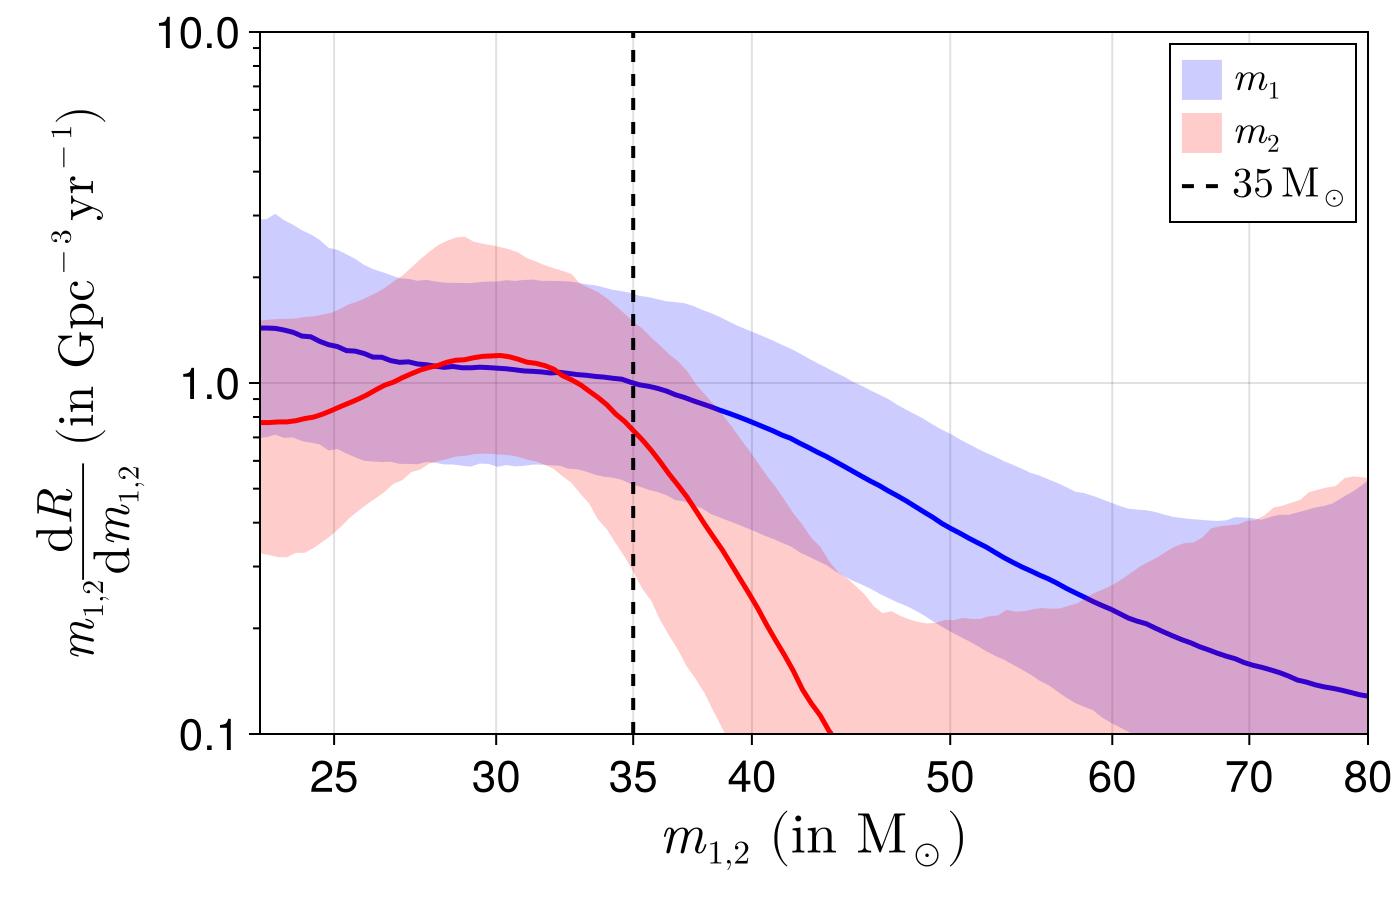

In [7]:
z_plot = 0.0

function marginal_m1m2_plot_paper(trace;
    limits=(23.0, 80.0, 0.1, 10.0),
    yticks=[0.01, 0.1, 1, 10, 100],
    yminorticks=[0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,
                 0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,2,3,4,5,6,7,8,9,20],
    draws=1000,
    rng=Random.default_rng()
)
    f = Figure(size=(700, 450))
    a = Axis(f[1,1],
        xlabel = L"m_{1,2}~(\mathrm{in~}\mathrm{M}_\odot)",
        ylabel = L"m_{1,2} \frac{\mathrm{d} R}{\mathrm{d} m_{1,2}}~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1})",
        xscale = log10, yscale = log10,
        xticks = [25, 30, 35, 40, 50, 60, 70, 80],
        xtickformat = "{:.0f}",
        yticks = (yticks, string.(yticks)),
        yminorticks = yminorticks, yminorticksvisible = true,
        xlabelsize = 28, ylabelsize = 25,
        xticklabelsize = 22, yticklabelsize = 22,
        limits = limits
    )

    # m1
    marginal_component_plot!(a, trace; kind=:m1, z_plot=z_plot,
        ms=exp.(log(m_bh_min):0.01:log(m_bh_max)),
        qs=0.001:0.01:1,
        draws=draws,
        rng=rng,
        color=:blue,
        label=L"m_1"
    )

    # m2
    marginal_component_plot!(a, trace; kind=:m2, z_plot=z_plot,
        ms=exp.(log(20.0):0.01:log(m_bh_max)),
        qs=0.001:0.01:1,
        draws=draws,
        rng=rng,
        color=:red,
        label=L"m_2"
    )

    # vertical line at 35
    vlines!(a, [35.0], color=:black, linewidth=2, linestyle=:dash, label=L"35\,\mathrm{M}_\odot")

    axislegend(a, position=:rt, labelsize=21, framevisible=true)

    f
end


function marginal_component_plot!(a, trace;
    kind::Symbol, z_plot,
    ms, qs, draws,
    rng, color, label
)
    p = trace.posterior
    dN_matrix = zeros(length(ms), draws)

    @progress for i in 1:draws
        d = rand(rng, span(dims(p, :draw)))
        c = rand(rng, 1:length(dims(p, :chain)))
        log_dN = log_dN_from_chain_sample(trace, d, c)

        vals = map(ms) do m
            integrand = map(qs) do q
                if kind == :m1
                    m2 = q * m
                    if m2 < m_bh_min
                        zero(m)
                    else
                        exp(log_dN(m, q, z_plot))
                    end
                elseif kind == :m2
                    m1 = m / q
                    if m1 < m_bh_min || m1 > m_bh_max
                        zero(m)
                    else
                        exp(log_dN(m1, q, z_plot)) / q
                    end
                end
            end
            m * p.R[chain=c, draw=d] * trapz(qs, integrand)
        end

        dN_matrix[:, i] = vals
    end

    q5 = mapslices(x -> quantile(x, 0.05), dN_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), dN_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), dN_matrix; dims=2)[:]

    band!(a, ms, q5, q95, color=(color, 0.2), label=label)
    lines!(a, ms, q50, color=color, linewidth=2.5)
end

f = marginal_m1m2_plot_paper(trace)
if plot_save
    save(outdir * "m1m2_marginal_population.pdf", f, px_per_unit=3)
end
f


### Robustness to the Choice of Mass Cut

#### with $p_{\rm cut}=0.5$ and $p_{\rm cut}=0.1$

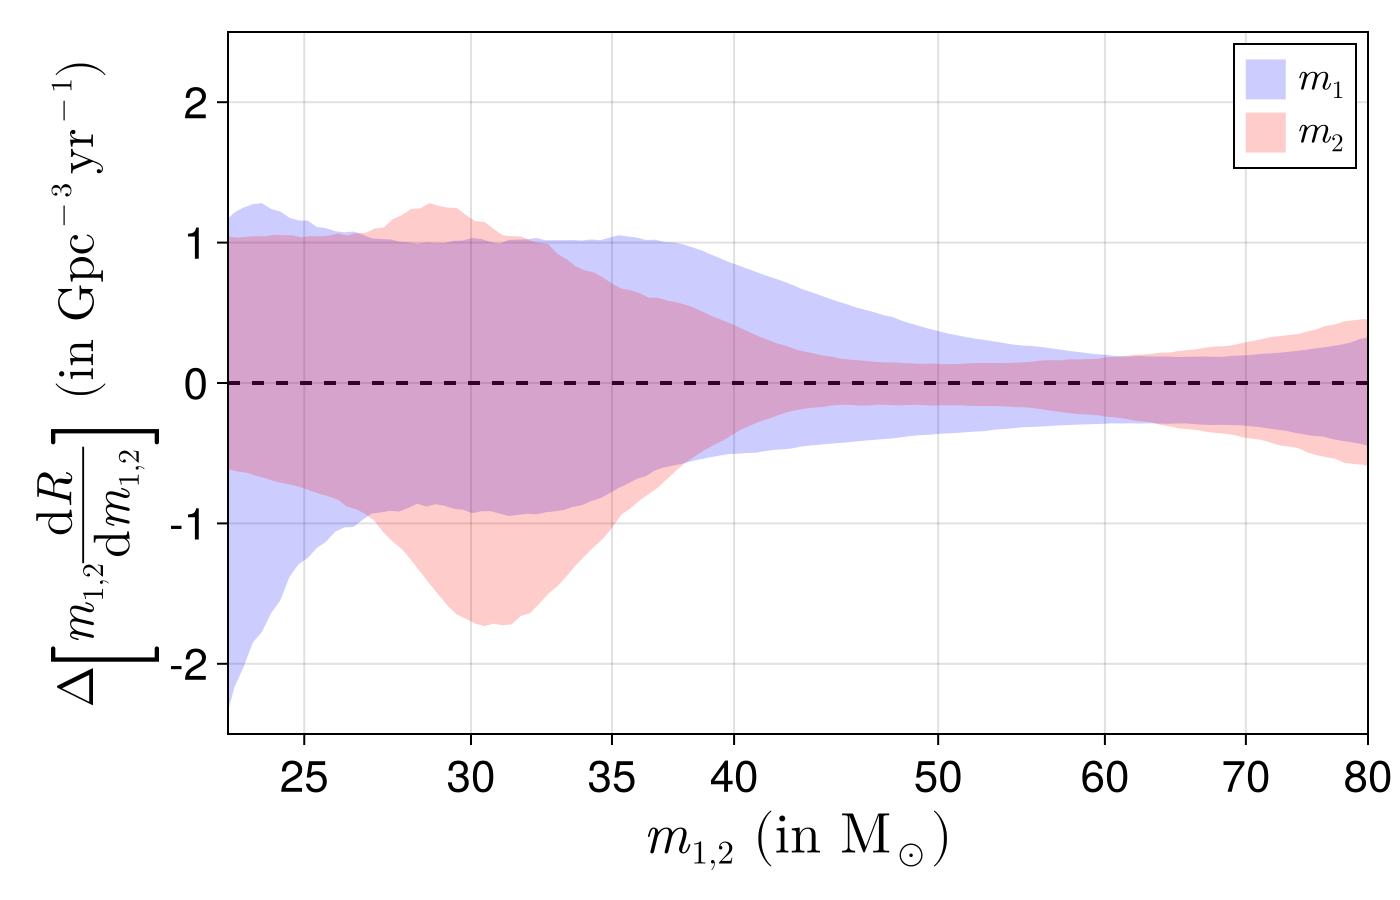

In [8]:
z_plot = 0.0

function summarize_matrix(rate_matrix)
    q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]
    return q5, q50, q95
end


function marginal_component_matrix(trace;
    kind::Symbol,
    z_plot,
    ms,
    qs,
    draws,
    rng
)
    p = trace.posterior
    dN_matrix = zeros(length(ms), draws)

    @progress for i in 1:draws
        d = rand(rng, span(dims(p, :draw)))
        c = rand(rng, 1:length(dims(p, :chain)))
        log_dN = log_dN_from_chain_sample(trace, d, c)

        vals = map(ms) do m
            integrand = map(qs) do q
                if kind == :m1
                    m2 = q * m
                    if m2 < m_bh_min
                        zero(m)
                    else
                        exp(log_dN(m, q, z_plot))
                    end
                elseif kind == :m2
                    m1 = m / q
                    if m1 < m_bh_min || m1 > m_bh_max
                        zero(m)
                    else
                        exp(log_dN(m1, q, z_plot)) / q
                    end
                end
            end
            m * p.R[chain=c, draw=d] * trapz(qs, integrand)
        end

        dN_matrix[:, i] = vals
    end

    return dN_matrix
end


function marginal_m1m2_difference_plot_paper(trace1, trace2;
    z_plot = z_plot,
    limits = (23.0, 80.0, -2.5, 2.5),
    yticks = [-2, -1, 0, 1, 2],
    ms_m1 = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    ms_m2 = exp.(log(20.0):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    draws = 1000,
    rng = Random.default_rng()
)
    m1_matrix_1 = marginal_component_matrix(
        trace1;
        kind = :m1,
        z_plot = z_plot,
        ms = ms_m1,
        qs = qs,
        draws = draws,
        rng = rng
    )

    m1_matrix_2 = marginal_component_matrix(
        trace2;
        kind = :m1,
        z_plot = z_plot,
        ms = ms_m1,
        qs = qs,
        draws = draws,
        rng = rng
    )

    m2_matrix_1 = marginal_component_matrix(
        trace1;
        kind = :m2,
        z_plot = z_plot,
        ms = ms_m2,
        qs = qs,
        draws = draws,
        rng = rng
    )

    m2_matrix_2 = marginal_component_matrix(
        trace2;
        kind = :m2,
        z_plot = z_plot,
        ms = ms_m2,
        qs = qs,
        draws = draws,
        rng = rng
    )

    diff_m1 = m1_matrix_1 .- m1_matrix_2
    diff_m2 = m2_matrix_1 .- m2_matrix_2

    m1_q5, _, m1_q95 = summarize_matrix(diff_m1)
    m2_q5, _, m2_q95 = summarize_matrix(diff_m2)

    f = Figure(size=(700, 450))
    a = Axis(
        f[1,1],
        xlabel = L"m_{1,2}~(\mathrm{in~}\mathrm{M}_\odot)",
        ylabel = L"\Delta\!\left[m_{1,2}\frac{\mathrm{d}R}{\mathrm{d}m_{1,2}}\right]~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1})",
        xscale = log10,
        xticks = [25, 30, 35, 40, 50, 60, 70, 80],
        xtickformat = "{:.0f}",
        yticks = (yticks, string.(yticks)),
        xlabelsize = 28,
        ylabelsize = 25,
        xticklabelsize = 22,
        yticklabelsize = 22,
        limits = limits,
        xgridvisible = true,
        ygridvisible = true
    )

    hlines!(a, [0.0], color=:black, linewidth=2, linestyle=:dash)

    band!(a, ms_m1, m1_q5, m1_q95, color=(:blue, 0.20), label=L"m_1")
    band!(a, ms_m2, m2_q5, m2_q95, color=(:red, 0.20), label=L"m_2")

    axislegend(a, position=:rt, labelsize=21, framevisible=true)

    return f
end


f_diff = marginal_m1m2_difference_plot_paper(
    trace,
    trace_samples_0p1;
    z_plot = z_plot,
    limits = (23.0, 80.0, -2.5, 2.5),
    yticks = [-2, -1, 0, 1, 2],
    ms_m1 = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    ms_m2 = exp.(log(20.0):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    draws = 1000,
    rng = Random.default_rng()
)

if plot_save
    save(outdir * "m1m2_marginal_population_diff_0p5_0p1.pdf", f_diff, px_per_unit=3)
end

f_diff

#### with $p_{\rm cut}=0.5$ and $p_{\rm cut}=0.9$

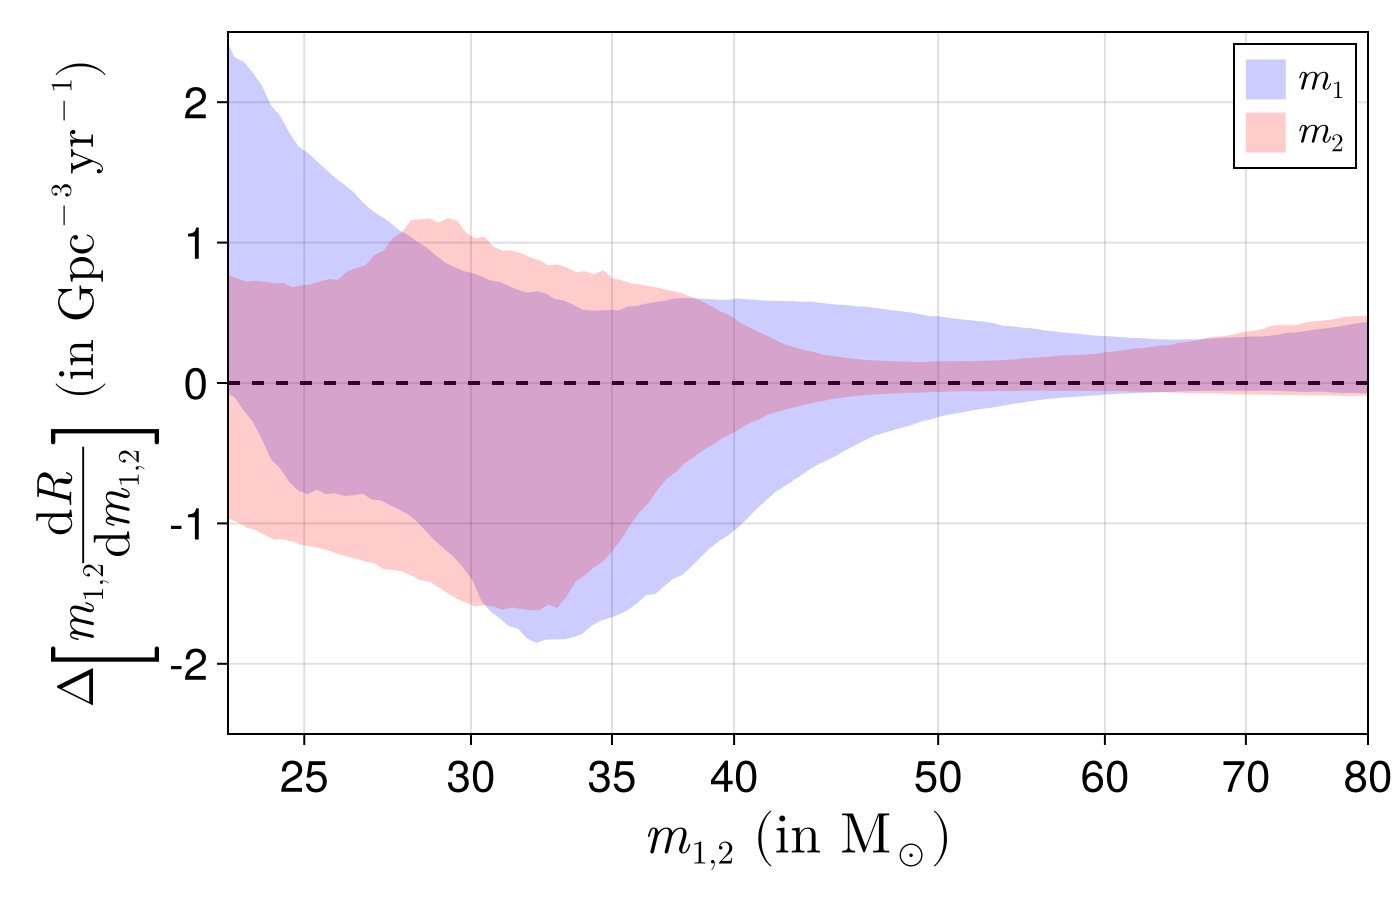

In [9]:
z_plot = 0.0

function summarize_matrix(rate_matrix)
    q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]
    return q5, q50, q95
end


function marginal_component_matrix(trace;
    kind::Symbol,
    z_plot,
    ms,
    qs,
    draws,
    rng
)
    p = trace.posterior
    dN_matrix = zeros(length(ms), draws)

    @progress for i in 1:draws
        d = rand(rng, span(dims(p, :draw)))
        c = rand(rng, 1:length(dims(p, :chain)))
        log_dN = log_dN_from_chain_sample(trace, d, c)

        vals = map(ms) do m
            integrand = map(qs) do q
                if kind == :m1
                    m2 = q * m
                    if m2 < m_bh_min
                        zero(m)
                    else
                        exp(log_dN(m, q, z_plot))
                    end
                elseif kind == :m2
                    m1 = m / q
                    if m1 < m_bh_min || m1 > m_bh_max
                        zero(m)
                    else
                        exp(log_dN(m1, q, z_plot)) / q
                    end
                end
            end
            m * p.R[chain=c, draw=d] * trapz(qs, integrand)
        end

        dN_matrix[:, i] = vals
    end

    return dN_matrix
end


function marginal_m1m2_difference_plot_paper(trace1, trace2;
    z_plot = z_plot,
    limits = (23.0, 80.0, -2.5, 2.5),
    yticks = [-2, -1, 0, 1, 2],
    ms_m1 = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    ms_m2 = exp.(log(20.0):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    draws = 1000,
    rng = Random.default_rng()
)
    m1_matrix_1 = marginal_component_matrix(
        trace1;
        kind = :m1,
        z_plot = z_plot,
        ms = ms_m1,
        qs = qs,
        draws = draws,
        rng = rng
    )

    m1_matrix_2 = marginal_component_matrix(
        trace2;
        kind = :m1,
        z_plot = z_plot,
        ms = ms_m1,
        qs = qs,
        draws = draws,
        rng = rng
    )

    m2_matrix_1 = marginal_component_matrix(
        trace1;
        kind = :m2,
        z_plot = z_plot,
        ms = ms_m2,
        qs = qs,
        draws = draws,
        rng = rng
    )

    m2_matrix_2 = marginal_component_matrix(
        trace2;
        kind = :m2,
        z_plot = z_plot,
        ms = ms_m2,
        qs = qs,
        draws = draws,
        rng = rng
    )

    diff_m1 = m1_matrix_1 .- m1_matrix_2
    diff_m2 = m2_matrix_1 .- m2_matrix_2

    m1_q5, _, m1_q95 = summarize_matrix(diff_m1)
    m2_q5, _, m2_q95 = summarize_matrix(diff_m2)

    f = Figure(size=(700, 450))
    a = Axis(
        f[1,1],
        xlabel = L"m_{1,2}~(\mathrm{in~}\mathrm{M}_\odot)",
        ylabel = L"\Delta\!\left[m_{1,2}\frac{\mathrm{d}R}{\mathrm{d}m_{1,2}}\right]~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1})",
        xscale = log10,
        xticks = [25, 30, 35, 40, 50, 60, 70, 80],
        xtickformat = "{:.0f}",
        yticks = (yticks, string.(yticks)),
        xlabelsize = 28,
        ylabelsize = 25,
        xticklabelsize = 22,
        yticklabelsize = 22,
        limits = limits,
        xgridvisible = true,
        ygridvisible = true
    )

    hlines!(a, [0.0], color=:black, linewidth=2, linestyle=:dash)

    band!(a, ms_m1, m1_q5, m1_q95, color=(:blue, 0.20), label=L"m_1")
    band!(a, ms_m2, m2_q5, m2_q95, color=(:red, 0.20), label=L"m_2")

    axislegend(a, position=:rt, labelsize=21, framevisible=true)

    return f
end


f_diff = marginal_m1m2_difference_plot_paper(
    trace,
    trace_samples_0p9;
    z_plot = z_plot,
    limits = (23.0, 80.0, -2.5, 2.5),
    yticks = [-2, -1, 0, 1, 2],
    ms_m1 = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    ms_m2 = exp.(log(20.0):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    draws = 1000,
    rng = Random.default_rng()
)

# if plot_save
#     save(outdir * "m1m2_marginal_population_diff_0p5_0p9.pdf", f_diff, px_per_unit=3)
# end

f_diff

# $q$ Conditioned on $m_1$

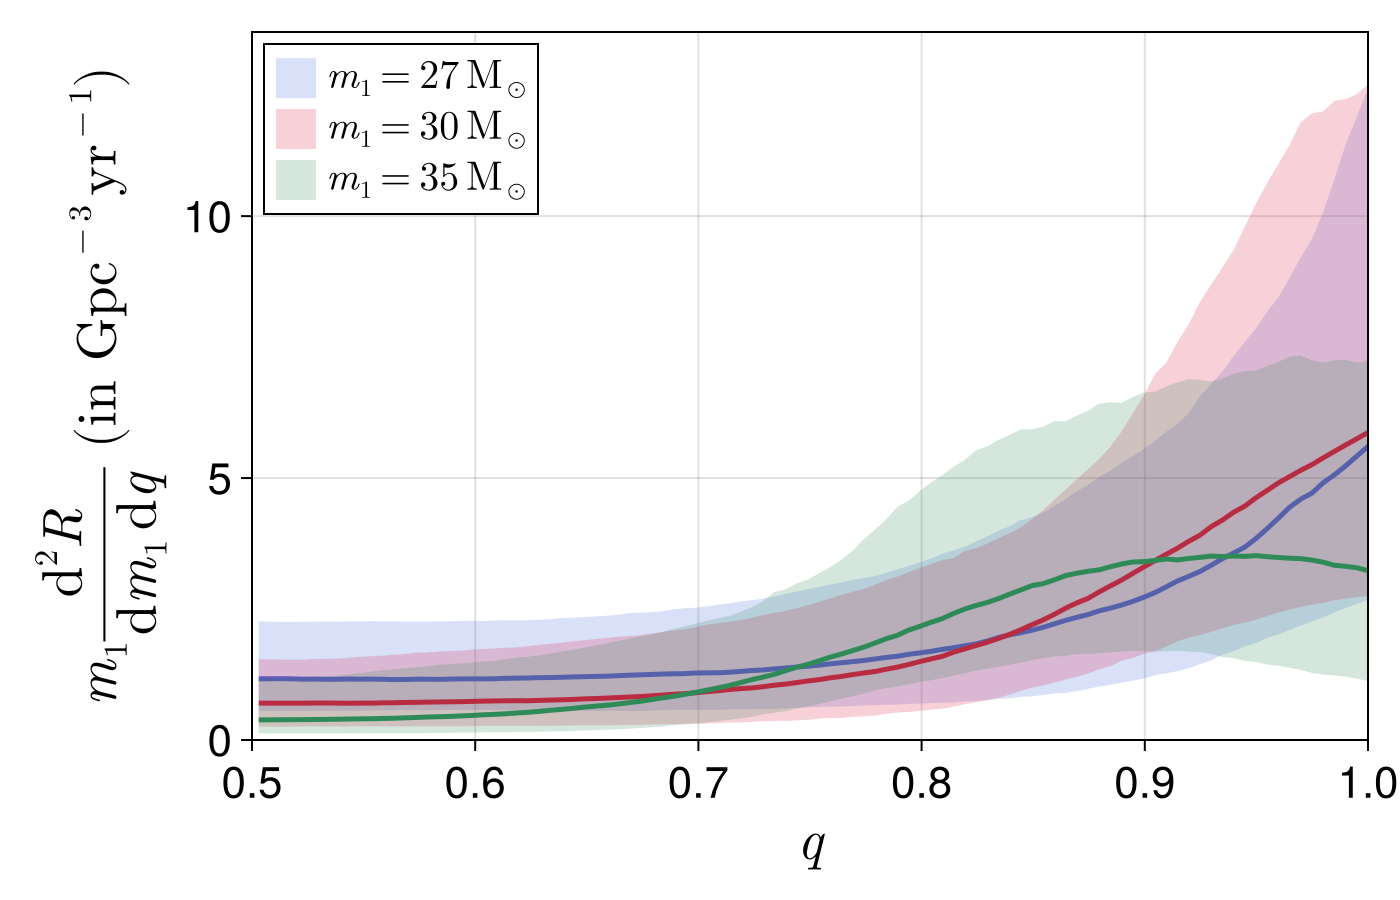

In [10]:
z_plot = 0.0

function conditional_rate_q_given_m1_plot_paper(trace;
    z_plot = z_plot,
    m1_targets = [27.0, 30.0, 35.0],
    qs = collect(range(0.001, stop=1.0, length=200)),
    draws = 1000,
    rng = Random.default_rng(),
    xlimits = (0.5, 1.0),
    colors = [:royalblue, :crimson, :seagreen]
)

    p = trace.posterior
    nq = length(qs)
    nt = length(m1_targets)

    q5_all  = Vector{Vector{Float64}}(undef, nt)
    q50_all = Vector{Vector{Float64}}(undef, nt)
    q95_all = Vector{Vector{Float64}}(undef, nt)

    global_ymax = 0.0

    for (k, m1_fix) in enumerate(m1_targets)

        rate_matrix = zeros(nq, draws)

        @progress for i in 1:draws

            d = rand(rng, span(dims(p, :draw)))
            c = rand(rng, 1:length(dims(p, :chain)))

            log_dN = log_dN_from_chain_sample(trace, d, c)
            Rcd = p.R[chain=c, draw=d]

            vals = map(qs) do q
                m2 = q * m1_fix

                if m1_fix <= 25.0 || m2 >= 40.0
                    0.0
                elseif m2 < m_bh_min || m2 > m1_fix || m1_fix > m_bh_max
                    0.0
                else
                    m1_fix * Rcd * exp(log_dN(m1_fix, q, z_plot))
                end
            end

            rate_matrix[:, i] .= vals
        end

        q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
        q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
        q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]

        q5_all[k]  = q5
        q50_all[k] = q50
        q95_all[k] = q95

        sel = qs .>= xlimits[1]
        ymax_here = maximum(q95[sel])
        global_ymax = max(global_ymax, ymax_here)
    end

    f = Figure(size=(700, 450))

    a = Axis(
        f[1,1],
        xlabel = L"q",
        ylabel = L"m_1\frac{\mathrm{d}^2R}{\mathrm{d}m_1\,\mathrm{d}q} ~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1})",
        limits = (xlimits[1], xlimits[2], 0.0, 1.08 * global_ymax),
        xticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = 22,
        yticklabelsize = 22,
        xgridvisible = true,
        ygridvisible = true
    )

    for (k, m1_fix) in enumerate(m1_targets)

        q5  = q5_all[k]
        q50 = q50_all[k]
        q95 = q95_all[k]

        valid = (qs .>= xlimits[1]) .& (q95 .> 0)

        band!(
            a,
            qs[valid],
            q5[valid],
            q95[valid],
            color = (colors[k], 0.20),
            label = L"m_1 = %$(Int(round(m1_fix)))\,\mathrm{M}_\odot"
        )

        lines!(
            a,
            qs[valid],
            q50[valid],
            color = colors[k],
            linewidth = 2.5
        )
    end

    axislegend(
        a,
        position = :lt,
        labelsize = 20,
        framevisible = true
    )

    return f
end


f = conditional_rate_q_given_m1_plot_paper(trace)

if plot_save
    save(outdir * "q_given_m1_rate.pdf", f, px_per_unit=3)
end

f

### Robustness to the Choice of Mass Cut

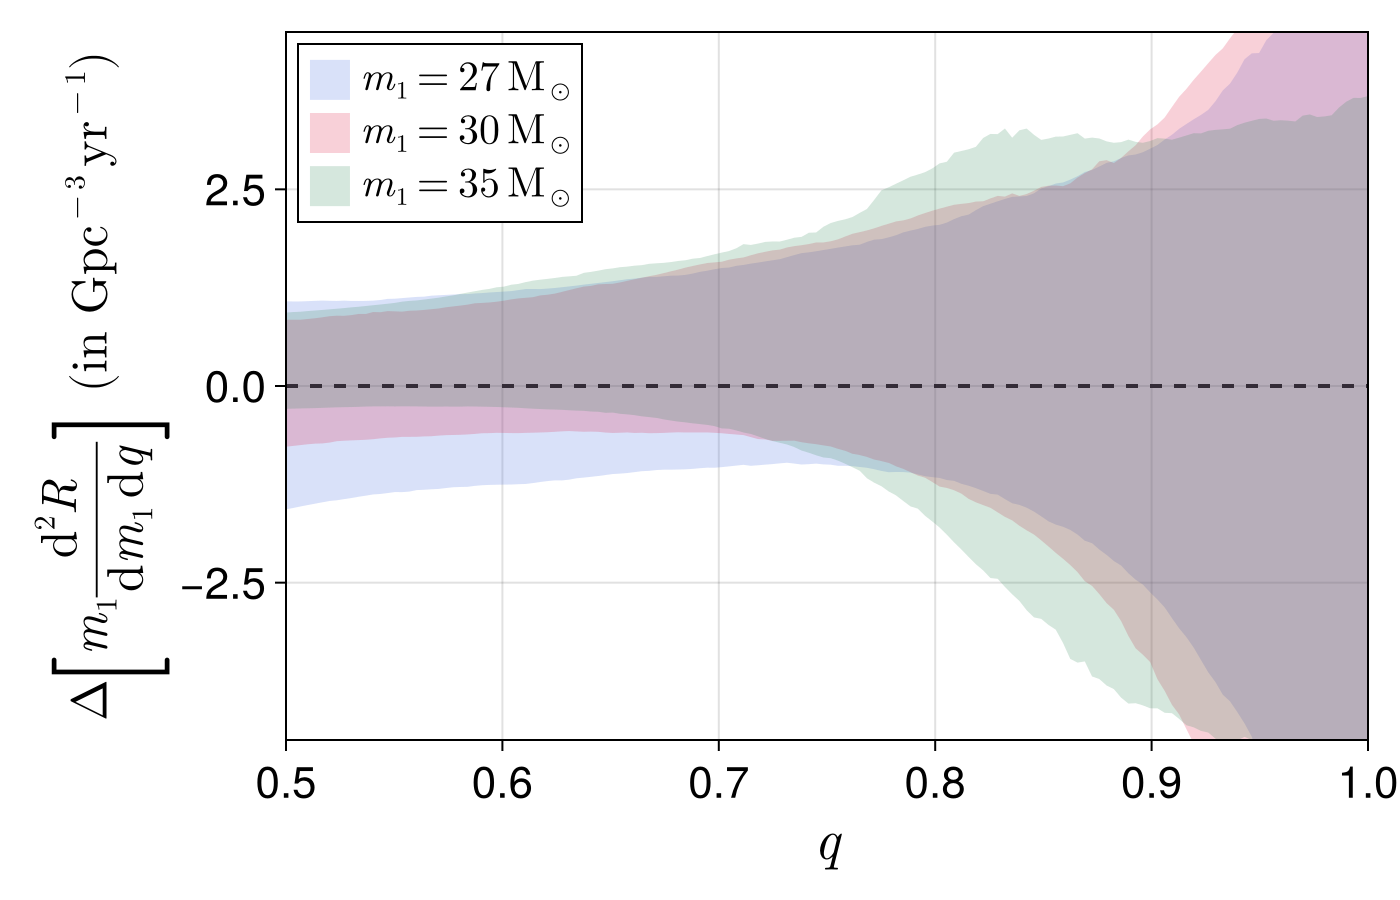

In [11]:
z_plot = 0.0

function conditional_rate_matrix(trace;
    z_plot = z_plot,
    m1_targets = [27.0, 30.0, 35.0],
    qs = collect(range(0.001, stop=1.0, length=200)),
    draws = 1000,
    rng = Random.default_rng()
)
    p = trace.posterior
    nq = length(qs)
    nt = length(m1_targets)

    rate_matrices = [zeros(nq, draws) for _ in 1:nt]

    for (k, m1_fix) in enumerate(m1_targets)
        @progress for i in 1:draws
            d = rand(rng, span(dims(p, :draw)))
            c = rand(rng, 1:length(dims(p, :chain)))

            log_dN = log_dN_from_chain_sample(trace, d, c)
            Rcd = p.R[chain=c, draw=d]

            vals = map(qs) do q
                m2 = q * m1_fix

                if m1_fix <= 25.0 || m2 >= 40.0
                    0.0
                elseif m2 < m_bh_min || m2 > m1_fix || m1_fix > m_bh_max
                    0.0
                else
                    m1_fix * Rcd * exp(log_dN(m1_fix, q, z_plot))
                end
            end

            rate_matrices[k][:, i] .= vals
        end
    end

    return rate_matrices
end


function summarize_matrix(rate_matrix)
    q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]
    return q5, q50, q95
end


function conditional_rate_difference_plot_paper(trace1, trace2;
    z_plot = z_plot,
    m1_targets = [27.0, 30.0, 35.0],
    qs = collect(range(0.5, stop=1.0, length=150)),
    draws = 1000,
    rng = Random.default_rng(),
    xlimits = (0.5, 1.0),
    ylimits = (-4.5, 4.5),
    colors = [:royalblue, :crimson, :seagreen]
)

    nt = length(m1_targets)

    rate_matrices_1 = conditional_rate_matrix(
        trace1;
        z_plot = z_plot,
        m1_targets = m1_targets,
        qs = qs,
        draws = draws,
        rng = rng
    )

    rate_matrices_2 = conditional_rate_matrix(
        trace2;
        z_plot = z_plot,
        m1_targets = m1_targets,
        qs = qs,
        draws = draws,
        rng = rng
    )

    diff_q5_all  = Vector{Vector{Float64}}(undef, nt)
    diff_q95_all = Vector{Vector{Float64}}(undef, nt)

    for k in 1:nt
        diff_matrix = rate_matrices_1[k] .- rate_matrices_2[k]
        q5, _, q95 = summarize_matrix(diff_matrix)

        diff_q5_all[k]  = q5
        diff_q95_all[k] = q95
    end

    f = Figure(size=(700, 450))

    a = Axis(
        f[1, 1],
        xlabel = L"q",
        ylabel = L"\Delta\!\left[m_1 \frac{\mathrm{d}^2 R}{\mathrm{d} m_1 \,\mathrm{d} q}\right]~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1})",
        limits = (xlimits[1], xlimits[2], ylimits[1], ylimits[2]),
        xticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        xlabelsize = 28,
        ylabelsize = 25,
        xticklabelsize = 22,
        yticklabelsize = 22,
        xgridvisible = true,
        ygridvisible = true
    )

    hlines!(a, [0.0], color=:black, linewidth=2, linestyle=:dash)

    for (k, m1_fix) in enumerate(m1_targets)
        q5  = diff_q5_all[k]
        q95 = diff_q95_all[k]

        band!(
            a,
            qs,
            q5,
            q95,
            color=(colors[k], 0.20),
            label=L"m_1 = %$(Int(round(m1_fix)))\,\mathrm{M}_\odot"
        )
    end

    axislegend(
        a,
        position=:lt,
        labelsize=21,
        framevisible=true
    )

    return f
end


f_diff = conditional_rate_difference_plot_paper(
    trace,
    trace_samples_0p1;
    z_plot = z_plot,
    m1_targets = [27.0, 30.0, 35.0],
    qs = collect(range(0.5, stop=1.0, length=150)),
    draws = 1000,
    rng = Random.default_rng(),
    xlimits = (0.5, 1.0),
    ylimits = (-4.5, 4.5),
    colors = [:royalblue, :crimson, :seagreen]
)

if plot_save
    save(outdir * "q_given_m1_rate_diff_0p5_0p1.pdf", f_diff, px_per_unit=3)
end

f_diff

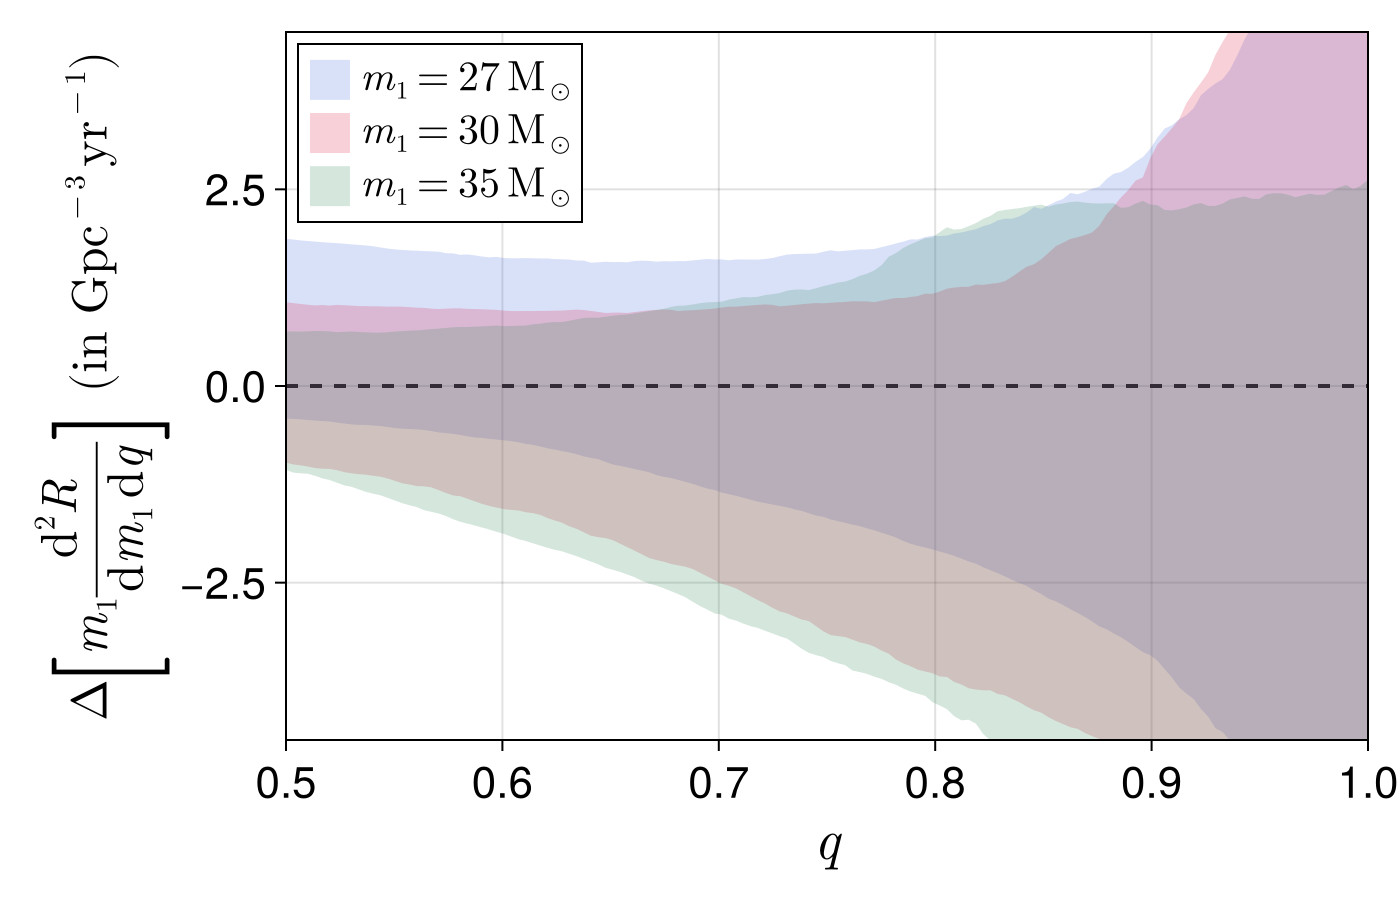

In [12]:
z_plot = 0.0

function conditional_rate_matrix(trace;
    z_plot = z_plot,
    m1_targets = [27.0, 30.0, 35.0],
    qs = collect(range(0.001, stop=1.0, length=200)),
    draws = 1000,
    rng = Random.default_rng()
)
    p = trace.posterior
    nq = length(qs)
    nt = length(m1_targets)

    rate_matrices = [zeros(nq, draws) for _ in 1:nt]

    for (k, m1_fix) in enumerate(m1_targets)
        @progress for i in 1:draws
            d = rand(rng, span(dims(p, :draw)))
            c = rand(rng, 1:length(dims(p, :chain)))

            log_dN = log_dN_from_chain_sample(trace, d, c)
            Rcd = p.R[chain=c, draw=d]

            vals = map(qs) do q
                m2 = q * m1_fix

                if m1_fix <= 25.0 || m2 >= 40.0
                    0.0
                elseif m2 < m_bh_min || m2 > m1_fix || m1_fix > m_bh_max
                    0.0
                else
                    m1_fix * Rcd * exp(log_dN(m1_fix, q, z_plot))
                end
            end

            rate_matrices[k][:, i] .= vals
        end
    end

    return rate_matrices
end


function summarize_matrix(rate_matrix)
    q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]
    return q5, q50, q95
end


function conditional_rate_difference_plot_paper(trace1, trace2;
    z_plot = z_plot,
    m1_targets = [27.0, 30.0, 35.0],
    qs = collect(range(0.5, stop=1.0, length=150)),
    draws = 1000,
    rng = Random.default_rng(),
    xlimits = (0.5, 1.0),
    ylimits = (-4.5, 4.5),
    colors = [:royalblue, :crimson, :seagreen]
)

    nt = length(m1_targets)

    rate_matrices_1 = conditional_rate_matrix(
        trace1;
        z_plot = z_plot,
        m1_targets = m1_targets,
        qs = qs,
        draws = draws,
        rng = rng
    )

    rate_matrices_2 = conditional_rate_matrix(
        trace2;
        z_plot = z_plot,
        m1_targets = m1_targets,
        qs = qs,
        draws = draws,
        rng = rng
    )

    diff_q5_all  = Vector{Vector{Float64}}(undef, nt)
    diff_q95_all = Vector{Vector{Float64}}(undef, nt)

    for k in 1:nt
        diff_matrix = rate_matrices_1[k] .- rate_matrices_2[k]
        q5, _, q95 = summarize_matrix(diff_matrix)

        diff_q5_all[k]  = q5
        diff_q95_all[k] = q95
    end

    f = Figure(size=(700, 450))

    a = Axis(
        f[1, 1],
        xlabel = L"q",
        ylabel = L"\Delta\!\left[m_1 \frac{\mathrm{d}^2 R}{\mathrm{d} m_1 \,\mathrm{d} q}\right]~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1})",
        limits = (xlimits[1], xlimits[2], ylimits[1], ylimits[2]),
        xticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        xlabelsize = 28,
        ylabelsize = 25,
        xticklabelsize = 22,
        yticklabelsize = 22,
        xgridvisible = true,
        ygridvisible = true
    )

    hlines!(a, [0.0], color=:black, linewidth=2, linestyle=:dash)

    for (k, m1_fix) in enumerate(m1_targets)
        q5  = diff_q5_all[k]
        q95 = diff_q95_all[k]

        band!(
            a,
            qs,
            q5,
            q95,
            color=(colors[k], 0.20),
            label=L"m_1 = %$(Int(round(m1_fix)))\,\mathrm{M}_\odot"
        )
    end

    axislegend(
        a,
        position=:lt,
        labelsize=21,
        framevisible=true
    )

    return f
end


f_diff = conditional_rate_difference_plot_paper(
    trace,
    trace_samples_0p9;
    z_plot = z_plot,
    m1_targets = [27.0, 30.0, 35.0],
    qs = collect(range(0.5, stop=1.0, length=150)),
    draws = 1000,
    rng = Random.default_rng(),
    xlimits = (0.5, 1.0),
    ylimits = (-4.5, 4.5),
    colors = [:royalblue, :crimson, :seagreen]
)

# if plot_save
#     save(outdir * "q_given_m1_rate_diff_0p5_0p9.pdf", f_diff, px_per_unit=3)
# end

f_diff

# Marginal $z$

imin = 37


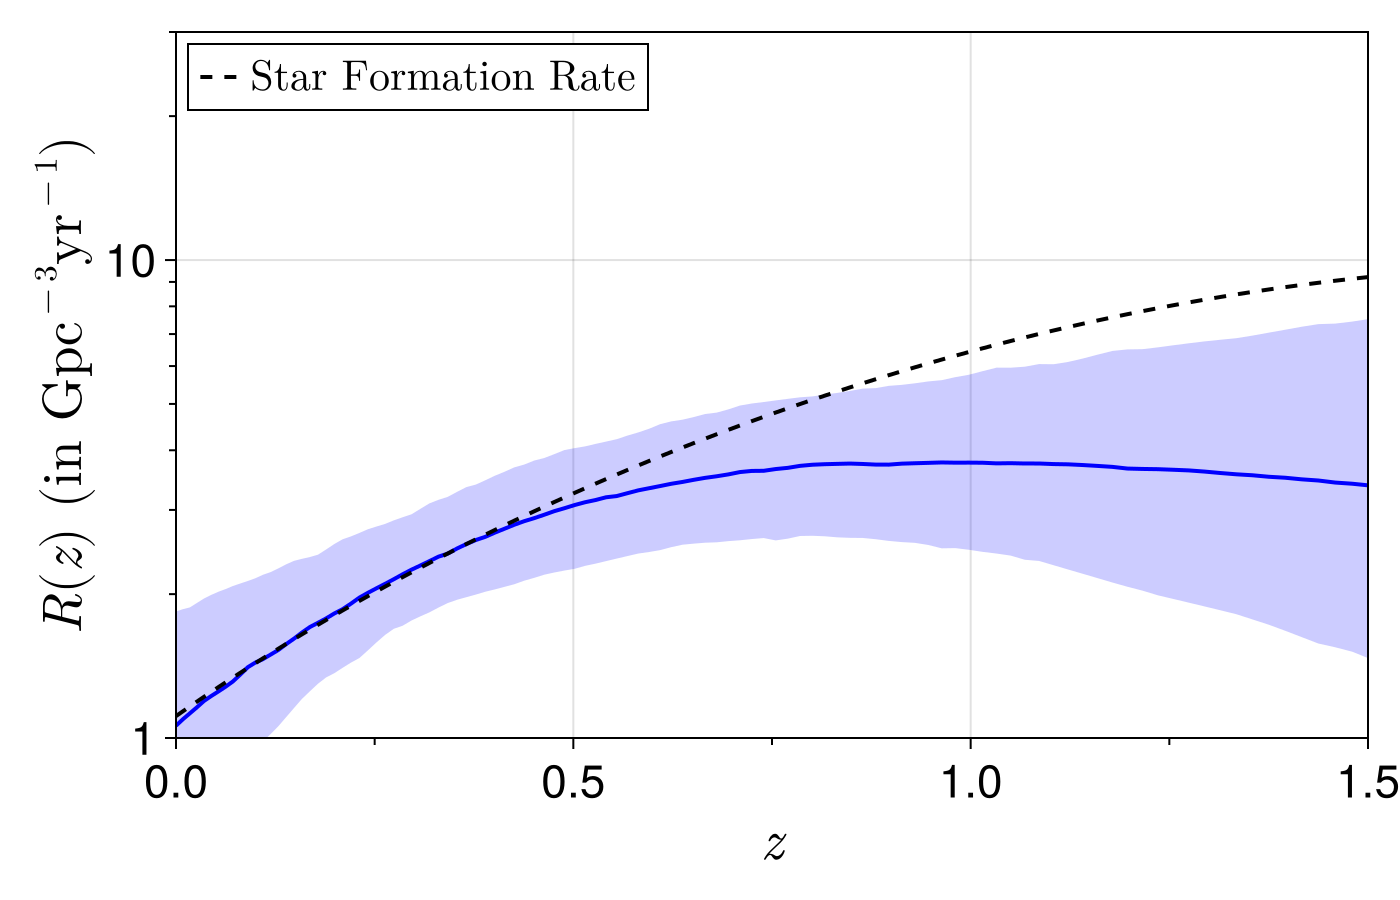

In [13]:
function marginal_z_plot_paper(trace;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng(),
    limits = (0, 1.5, 1, 30),
    yticks = [1, 10, 100, 1000],
    yminorticks = [2,3,4,5,6,7,8,9,20,30,40,50,60,70,80,90,200,300,400,500,600,700,800,900],
    plot_md_line = true,
    color = Makie.wong_colors()[1]
)
    f = Figure(size=(700, 450))
    a = Axis(f[1, 1],
        xlabel = L"z",
        ylabel = L"R(z)~(\mathrm{in~}\mathrm{Gpc}^{-3}\mathrm{yr}^{-1})",
        yscale = log10,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize,
        ytickformat = "{:.0f}",
        yticks = yticks,
        yminorticks = yminorticks,
        yminorticksvisible = true,
        xminorticksvisible = true,
        limits = limits
    )

    p = trace.posterior
    dNs = zeros(length(zs), draws)

    @progress for j in 1:draws
        c = rand(rng, span(dims(p, :chain)))
        d = rand(rng, span(dims(p, :draw)))
        log_dN = log_dN_from_chain_sample(trace, d, c)

        z1 = zs[1]
        dNdms = map(ms) do m
            integrand = map(qs) do q
                m2 = q * m
                if m2 < m_bh_min
                    zero(m)
                else
                    exp(log_dN(m, q, z1))
                end
            end
            trapz(qs, integrand)
        end

        norm = trace.posterior.R[draw=d, chain=c] *
               trapz(ms, dNdms) /
               exp(log_dN(m_plot, q_plot, z1))

        dNdz = map(zs) do z
            norm * exp(log_dN(m_plot, q_plot, z))
        end

        dNs[:, j] = dNdz
    end

    #imin = argmin(Rz_95 - Rz_5)
    vs = vec(var(log.(dNs), dims=2))
    imin = argmin(vs)
    @show imin
    
    medians = mapslices(median, dNs; dims=2)[:]
    lowers = mapslices(x -> quantile(x, 0.05), dNs; dims=2)[:]
    uppers = mapslices(x -> quantile(x, 0.95), dNs; dims=2)[:]
    norm = medians[imin]


    band_plot = band!(a, zs, lowers, uppers, color=(:blue, 0.2))
    median_plot = lines!(a, zs, medians, color=:blue, linewidth=2)

    sfr_plot = nothing
    if plot_md_line
        mds = @. (1 + zs)^2.7 / (1 + ((1 + zs)/(1 + 1.9))^5.6)
        mds = mds .* norm ./ mds[imin]

        sfr_plot = lines!(a, zs, mds, color=:black, linestyle=:dash, linewidth=2, label=L"\mathrm{Star~Formation~Rate}")
    end

    axislegend(a, position = :lt, labelsize = 21, framevisible = true)
    
    return f
end

f = marginal_z_plot_paper(trace)
if plot_save
    save(outdir * "z_marginal_population.pdf", f, px_per_unit=3)
end
f

### Robustness to the Choice of Mass Cut

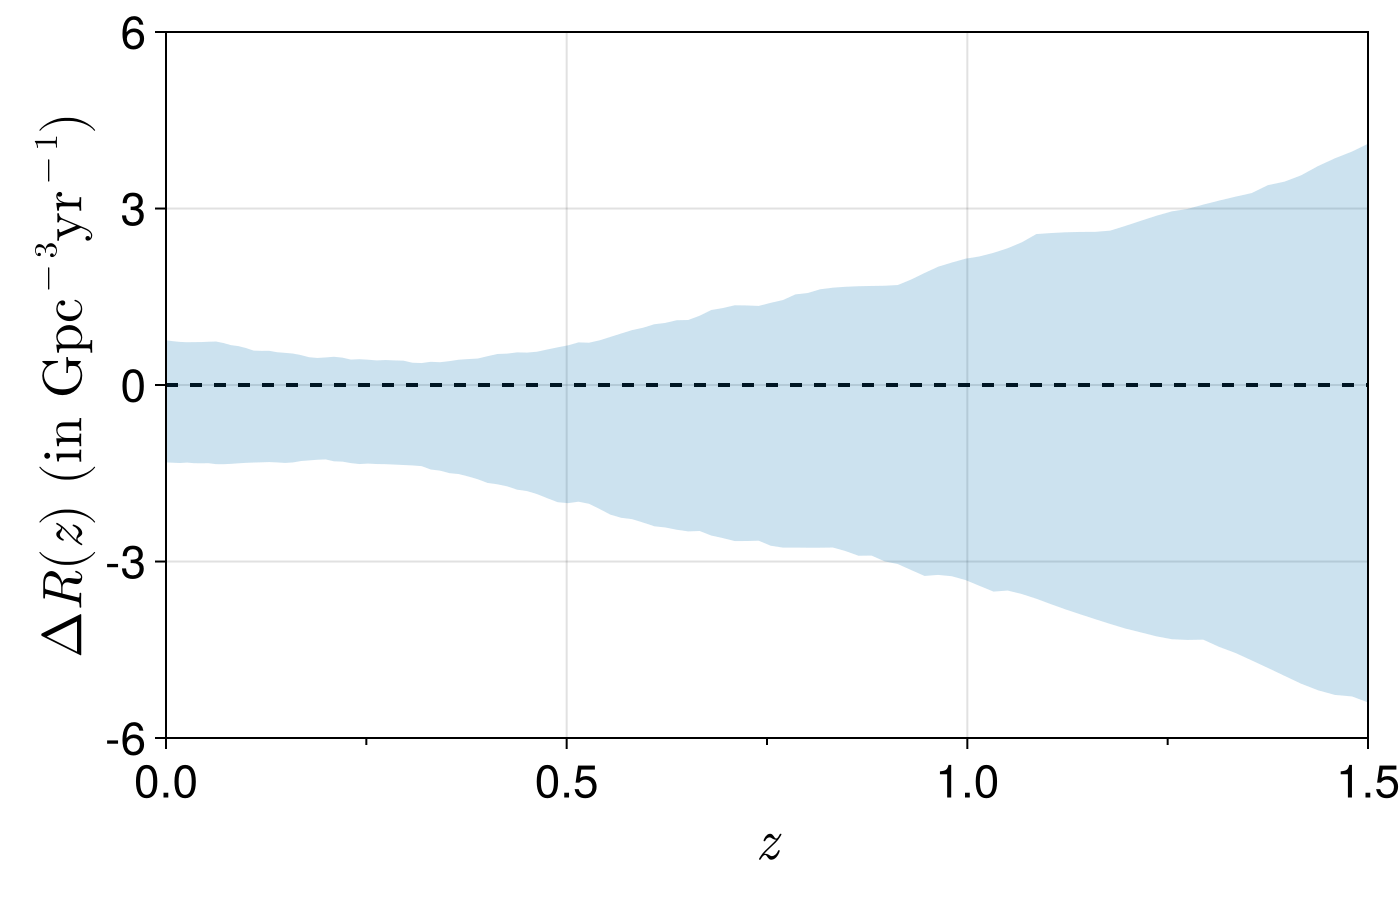

In [14]:
function summarize_matrix(rate_matrix)
    q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]
    return q5, q50, q95
end


function marginal_z_matrix(trace;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng()
)
    p = trace.posterior
    dNs = zeros(length(zs), draws)

    @progress for j in 1:draws
        c = rand(rng, span(dims(p, :chain)))
        d = rand(rng, span(dims(p, :draw)))
        log_dN = log_dN_from_chain_sample(trace, d, c)

        z1 = zs[1]
        dNdms = map(ms) do m
            integrand = map(qs) do q
                m2 = q * m
                if m2 < m_bh_min
                    zero(m)
                else
                    exp(log_dN(m, q, z1))
                end
            end
            trapz(qs, integrand)
        end

        norm = trace.posterior.R[draw=d, chain=c] *
               trapz(ms, dNdms) /
               exp(log_dN(m_plot, q_plot, z1))

        dNdz = map(zs) do z
            norm * exp(log_dN(m_plot, q_plot, z))
        end

        dNs[:, j] = dNdz
    end

    return dNs
end


function marginal_z_difference_plot_paper(trace1, trace2;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng(),
    limits = (0, 1.5, -6, 6),
    yticks = [-6, -3, 0, 3, 6],
    color = Makie.wong_colors()[1]
)
    dNs1 = marginal_z_matrix(
        trace1;
        ms = ms,
        qs = qs,
        zs = zs,
        draws = draws,
        rng = rng
    )

    dNs2 = marginal_z_matrix(
        trace2;
        ms = ms,
        qs = qs,
        zs = zs,
        draws = draws,
        rng = rng
    )

    diff_dNs = dNs1 .- dNs2
    lowers, _, uppers = summarize_matrix(diff_dNs)

    f = Figure(size=(700, 450))
    a = Axis(
        f[1, 1],
        xlabel = L"z",
        ylabel = L"\Delta R(z)~(\mathrm{in~}\mathrm{Gpc}^{-3}\mathrm{yr}^{-1})",
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize,
        ytickformat = "{:.0f}",
        yticks = yticks,
        xminorticksvisible = true,
        limits = limits
    )

    hlines!(a, [0.0], color=:black, linewidth=2, linestyle=:dash)

    band!(a, zs, lowers, uppers, color=(color, 0.2))

    return f
end

f_diff = marginal_z_difference_plot_paper(
    trace,
    trace_samples_0p1;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng(),
    limits = (0, 1.5, -6, 6),
    yticks = [-6, -3, 0, 3, 6],
    color = Makie.wong_colors()[1]
)

if plot_save
    save(outdir * "z_marginal_population_diff_0p5_0p1.pdf", f_diff, px_per_unit=3)
end

f_diff

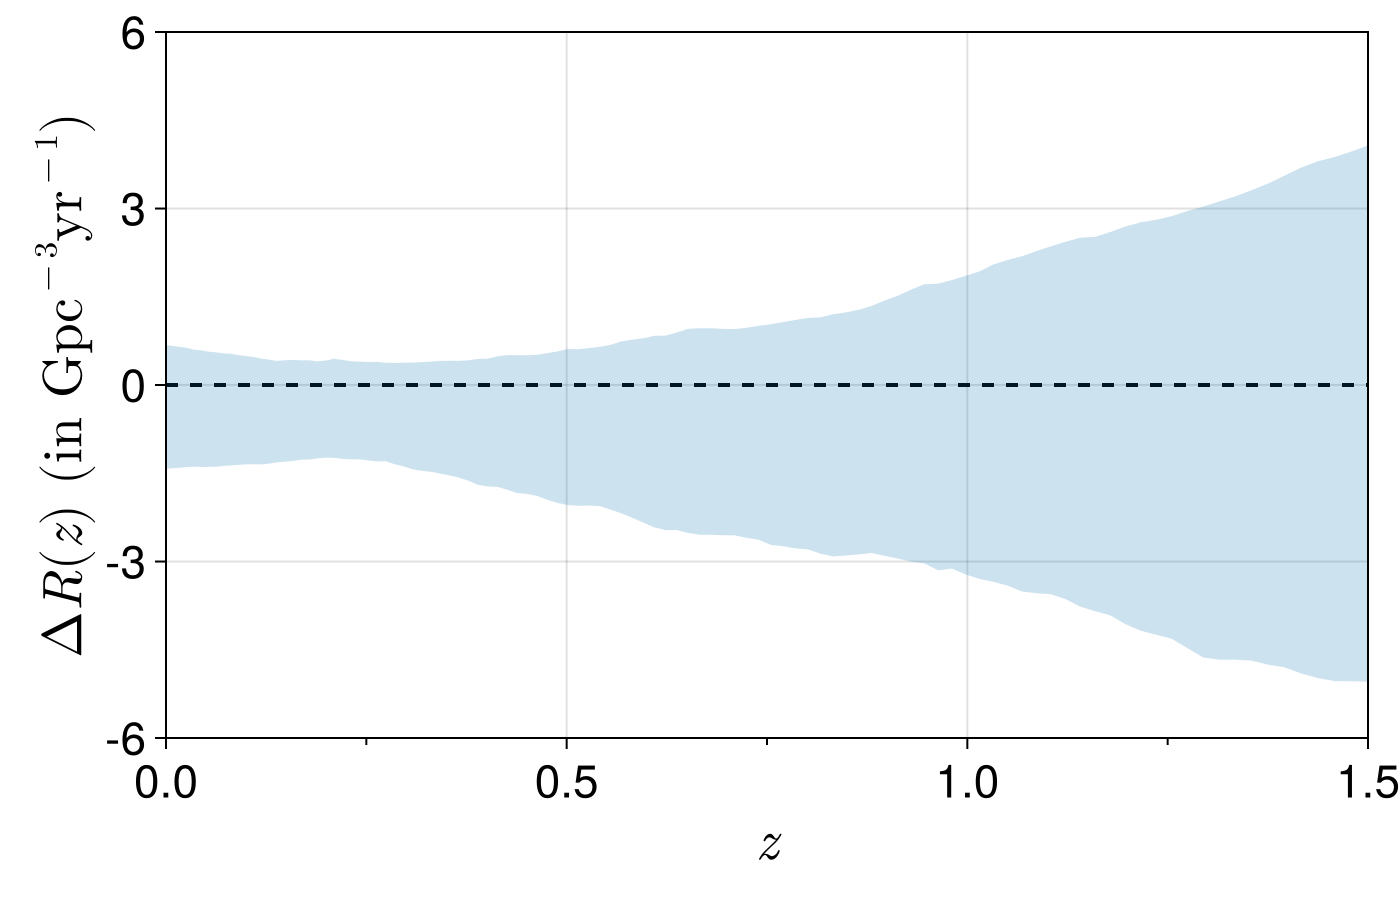

In [15]:
function summarize_matrix(rate_matrix)
    q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]
    return q5, q50, q95
end


function marginal_z_matrix(trace;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng()
)
    p = trace.posterior
    dNs = zeros(length(zs), draws)

    @progress for j in 1:draws
        c = rand(rng, span(dims(p, :chain)))
        d = rand(rng, span(dims(p, :draw)))
        log_dN = log_dN_from_chain_sample(trace, d, c)

        z1 = zs[1]
        dNdms = map(ms) do m
            integrand = map(qs) do q
                m2 = q * m
                if m2 < m_bh_min
                    zero(m)
                else
                    exp(log_dN(m, q, z1))
                end
            end
            trapz(qs, integrand)
        end

        norm = trace.posterior.R[draw=d, chain=c] *
               trapz(ms, dNdms) /
               exp(log_dN(m_plot, q_plot, z1))

        dNdz = map(zs) do z
            norm * exp(log_dN(m_plot, q_plot, z))
        end

        dNs[:, j] = dNdz
    end

    return dNs
end


function marginal_z_difference_plot_paper(trace1, trace2;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng(),
    limits = (0, 1.5, -6, 6),
    yticks = [-6, -3, 0, 3, 6],
    color = Makie.wong_colors()[1]
)
    dNs1 = marginal_z_matrix(
        trace1;
        ms = ms,
        qs = qs,
        zs = zs,
        draws = draws,
        rng = rng
    )

    dNs2 = marginal_z_matrix(
        trace2;
        ms = ms,
        qs = qs,
        zs = zs,
        draws = draws,
        rng = rng
    )

    diff_dNs = dNs1 .- dNs2
    lowers, _, uppers = summarize_matrix(diff_dNs)

    f = Figure(size=(700, 450))
    a = Axis(
        f[1, 1],
        xlabel = L"z",
        ylabel = L"\Delta R(z)~(\mathrm{in~}\mathrm{Gpc}^{-3}\mathrm{yr}^{-1})",
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize,
        ytickformat = "{:.0f}",
        yticks = yticks,
        xminorticksvisible = true,
        limits = limits
    )

    hlines!(a, [0.0], color=:black, linewidth=2, linestyle=:dash)

    band!(a, zs, lowers, uppers, color=(color, 0.2))

    return f
end

f_diff = marginal_z_difference_plot_paper(
    trace,
    trace_samples_0p1;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng(),
    limits = (0, 1.5, -6, 6),
    yticks = [-6, -3, 0, 3, 6],
    color = Makie.wong_colors()[1]
)

# if plot_save
#     save(outdir * "z_marginal_population_diff_0p5_0p9.pdf", f_diff, px_per_unit=3)
# end

f_diff